The <strong>MNIST database</strong>, short for Modified National Institute of Standards and Technology database, is a large database of handwritten digits that is commonly used for training various image processing systems. The database is also widely used for training and testing in the field of machine learning.
    
The MNIST database contains 60,000 training images and 10,000 testing images of digits written by high school students and employees of the United States Census Bureau.

Also, this way, you will get to compare how conventional neural networks compare to convolutional neural networks, that we will build in the next module.

## Objectives for this Notebook    
* Use the MNIST database for training various image processing systems
* Build a neural network
* Train and test the network


## Table of Contents

<div class="alert alert-block alert-info" style="margin-top: 20px">

<font size = 3>

1. <a href="#Import-Keras-and-Packages">Import Keras and Packages</a>      
2. <a href="#Build-a-Neural-Network">Build a Neural Network</a>     
3. <a href="#Train-and-Test-the-Network">Train and Test the Network</a>     

</font>
</div>

In [1]:
import keras

from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Input
from keras.utils import to_categorical


Since we are dealing we images, let's also import the Matplotlib scripting layer in order to view the images.


In [2]:
import matplotlib.pyplot as plt

In [3]:
from keras.datasets import mnist 

In [4]:
(X_train,y_train),(X_test,y_test) =mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [5]:
X_train.shape

(60000, 28, 28)

The first number in the output tuple is the number of images, and the other two numbers are the size of the images in datset. So, each image is 28 pixels by 28 pixels.


The first number in the output tuple is the number of images, and the other two numbers are the size of the images in datset. So, each image is 28 pixels by 28 pixels.


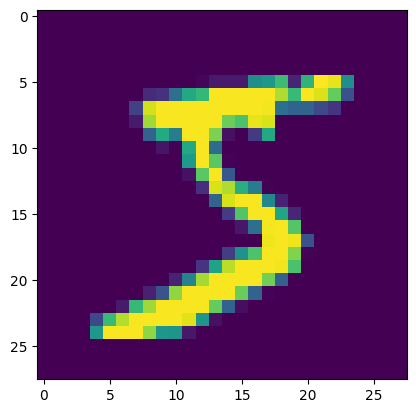

In [6]:
plt.imshow(X_train[0])

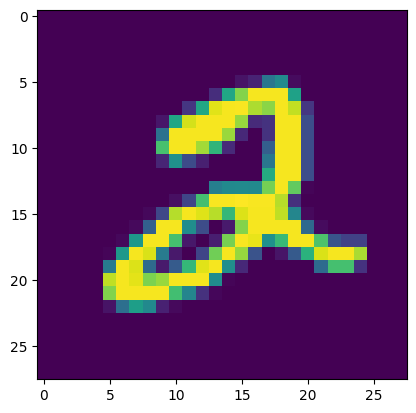

In [7]:
plt.imshow(X_train[5])

With conventional neural networks, we cannot feed in the image as input as is. So we need to flatten the images into one-dimensional vectors, each of size 1 x (28 x 28) = 1 x 784.


In [8]:
# flatten images into one-dimensional vector

num_pixels = X_train.shape[1] * X_train.shape[2] # find size of one-dimensional vector

X_train = X_train.reshape(X_train.shape[0], num_pixels).astype('float32') # flatten training images
X_test = X_test.reshape(X_test.shape[0], num_pixels).astype('float32') # flatten test images

Since pixel values can range from 0 to 255, let's normalize the vectors to be between 0 and 1.


In [9]:
# normalize inputs from 0-255 to 0-1
X_train = X_train / 255
X_test = X_test / 255

Finally, before we start building our model, remember that for classification we need to divide our target variable into categories. We use the to_categorical function from the Keras Utilities package.


In [10]:
#one hot encode outputs
y_train =to_categorical(y_train)
y_test =to_categorical(y_test)

num_classes=y_test.shape[1]
print(num_classes)


10


## Build a Neural Network


In [13]:
def classification_model():

    model=Sequential()
    model.add(Input(shape=(num_pixels,)))
    model.add(Dense(num_pixels,activation='relu'))
    model.add(Dense(100,activation='relu'))
    model.add(Dense(num_classes,activation='softmax'))

    model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
    return model

## Train and Test the Network

In [14]:
model =classification_model()

model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=10,verbose=2)

#evaluate the model 
scores=model.evaluate(X_test,y_test,verbose=0)

Epoch 1/10
1875/1875 - 8s - 4ms/step - accuracy: 0.9437 - loss: 0.1841 - val_accuracy: 0.9595 - val_loss: 0.1236
Epoch 2/10
1875/1875 - 8s - 4ms/step - accuracy: 0.9754 - loss: 0.0788 - val_accuracy: 0.9777 - val_loss: 0.0745
Epoch 3/10
1875/1875 - 8s - 4ms/step - accuracy: 0.9834 - loss: 0.0532 - val_accuracy: 0.9780 - val_loss: 0.0698
Epoch 4/10
1875/1875 - 7s - 4ms/step - accuracy: 0.9871 - loss: 0.0409 - val_accuracy: 0.9785 - val_loss: 0.0684
Epoch 5/10
1875/1875 - 8s - 4ms/step - accuracy: 0.9892 - loss: 0.0321 - val_accuracy: 0.9793 - val_loss: 0.0789
Epoch 6/10
1875/1875 - 7s - 4ms/step - accuracy: 0.9910 - loss: 0.0275 - val_accuracy: 0.9788 - val_loss: 0.0791
Epoch 7/10
1875/1875 - 8s - 4ms/step - accuracy: 0.9932 - loss: 0.0223 - val_accuracy: 0.9804 - val_loss: 0.0818
Epoch 8/10
1875/1875 - 7s - 4ms/step - accuracy: 0.9938 - loss: 0.0192 - val_accuracy: 0.9806 - val_loss: 0.0894
Epoch 9/10
1875/1875 - 7s - 4ms/step - accuracy: 0.9941 - loss: 0.0187 - val_accuracy: 0.9802 - 

In [15]:
print('Accuracy: {}% \n Error: {}'.format(scores[1], 1 - scores[1]))      

Accuracy: 0.9811999797821045% 
 Error: 0.018800020217895508


Sometimes, you cannot afford to retrain your model everytime you want to use it, especially if you are limited on computational resources and training your model can take a long time. Therefore, with the Keras library, you can save your model after training. To do that, we use the save method.


In [16]:
model.save('classification_model.keras')

Since our model contains multidimensional arrays of data, then models are usually saved as .keras files.


When you are ready to use your model again, you use the load_model function from <strong>keras.saving</strong>.


In [17]:
pretrained_model = keras.saving.load_model('classification_model.keras')